# Architektura Aplikacji w Pythonie — Zestaw Zaliczeniowy

**WSEI Kraków · semestr letni 2026 · prowadzący: Michał Madejski**

---

## Filozofia tego zestawu

Sześć laboratoriów dało Ci sześć narzędzi. Ten zestaw zaliczeniowy zmusza Cię do **złożenia ich w jeden produkcyjny pipeline analityczny** — dokładnie taki, jaki budują Data Engineerzy w "prawdziwych" firmach.

**Wspólny dataset:** [`stanfordnlp/imdb`](https://huggingface.co/datasets/stanfordnlp/imdb) z Hugging Face Hub — 50 000 recenzji filmów z etykietami sentymentu (pozytywna / negatywna).

**Reguły:**
1. Każdy lab ma blok: **Teoria → Przykład rozwiązany → Zadanie samodzielne**.
2. Zadania samodzielne **rozszerzają** przykład — dokładnie ten sam pattern, inny scenariusz.
3. Cały notebook ma być **uruchamialny od góry do dołu**. Brak hardkodowanych ścieżek, brak ręcznych downloadów.
4. Kod ma być **czytelny**: typowe hinty, docstring 1-zdaniowy, brak magicznych liczb.

**Ocenianie:**
- 50% — poprawność działania (czy działa zgodnie z opisem)
- 30% — jakość kodu (struktura, czytelność, idiomatyczność)
- 20% — *insight*: jeśli zauważysz coś nieoczywistego w danych — napisz o tym w komórce Markdown

---

## Mapa zestawu

| # | Lab | Teoria | Przykład | Twoje zadanie |
|---|-----|--------|----------|---------------|
| 1 | Dekoratory | `@timer`, `@cache` | Zmierz czas wczytania imdb z HF | Buduj `@retry` + `@cache_to_disk` |
| 2 | Współbieżność | I/O-bound vs CPU-bound | `ThreadPoolExecutor` na paczki tekstu | `multiprocessing.Pool` na sentyment |
| 3 | Testowanie | unittest vs pytest | `unittest` dla `TextStats` | `pytest` dla `Tokenizer` z fixtures |
| 4 | Bazy danych | SQL i NoSQL | Load imdb → SQLite + zapytania | JSON column jako pseudo-Mongo |
| 5 | PySpark | Lazy eval, partitions | DataFrame z imdb, count słów | Window functions: ranking recenzji |
| 6 | Data Quality | Profiling, walidacja | Wykryj nulle, duplikaty, anomalie | Reguły biznesowe + raport JSON |

---

## Setup

In [22]:
# Globalna konfiguracja -- jedna komorka, jeden raz
import os, sys, time, json, warnings, random
from pathlib import Path
warnings.filterwarnings("ignore")

WORKDIR = Path("./_workspace")
WORKDIR.mkdir(exist_ok=True)

# Tame log spamu HF Datasets
os.environ.setdefault("HF_DATASETS_DISABLE_PROGRESS_BAR", "1")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")

print(f"Python: {sys.version.split()[0]}")
print(f"Workspace: {WORKDIR.resolve()}")

Python: 3.14.3
Workspace: C:\Users\mitan\Magisterka\AAP_LAB_TASKS\zestaw_zaliczeniowy\_workspace


---

# Lab 1 — Dekoratory

## Teoria w trzech zdaniach

**Dekorator** to funkcja, która przyjmuje funkcję i zwraca funkcję. Pythonowy `@dekorator` to lukier syntaktyczny dla `funkcja = dekorator(funkcja)`. Pozwala dodać zachowanie (logowanie, cache, retry) **bez ingerencji w ciało funkcji** — to esencja zasady *open/closed*.

### Wzorzec dekoratora z argumentami

```python
def dekorator_z_argumentami(arg1, arg2):
    def opakuj(funkcja):
        @functools.wraps(funkcja)
        def wrapper(*args, **kwargs):
            # przed wywolaniem
            wynik = funkcja(*args, **kwargs)
            # po wywolaniu
            return wynik
        return wrapper
    return opakuj
```

Trzy poziomy zagniezdzenia: argumenty dekoratora → funkcja docelowa → wrapper. **Zapamiętaj ten układ raz — reszta to wariacje.**

## Przykład rozwiązany: `@timer` + `@cache` na ładowaniu z Hugging Face

In [23]:
import functools
from datasets import load_dataset

def timer(func):
    """Mierzy czas wykonania funkcji i drukuje wynik."""
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        t0 = time.time()
        result = func(*args, **kwargs)
        elapsed = time.time() - t0
        print(f"  [timer] {func.__name__} -> {elapsed:.2f}s")
        return result
    return wrapper

@timer
@functools.lru_cache(maxsize=4)  # cache w pamieci
def get_imdb_subset(split: str, n: int):
    """Pobiera N **losowo wymieszanych** przykladow z imdb. Cachuje wynik w RAM.

    UWAGA: dataset stanfordnlp/imdb jest na HF zsortowany po labelu
    (0..12499 = neg, 12500..24999 = pos). Bez shuffle dostalibysmy
    100% jednej klasy dla N <= 12500. .shuffle(seed=42) gwarantuje
    rownomierna probke.
    """
    ds = load_dataset("stanfordnlp/imdb", split=split).shuffle(seed=42).select(range(n))
    return [(r["text"], r["label"]) for r in ds]

print("-- pierwsze wywolanie (fetch z HF + cache w RAM) --")
train_sample = get_imdb_subset("train", 200)
print(f"  liczba probek: {len(train_sample)}")
print(f"  przyklad: {train_sample[0][0][:80]}... -> label={train_sample[0][1]}")

# Sanity check: czy mamy obie klasy?
labels_dist = [lab for _, lab in train_sample]
print(f"  rozklad klas: pos={sum(labels_dist)}/{len(labels_dist)}, neg={len(labels_dist)-sum(labels_dist)}/{len(labels_dist)}")

print("\n-- drugie wywolanie (powinno byc << 0.01s dzieki cache) --")
_ = get_imdb_subset("train", 200)

-- pierwsze wywolanie (fetch z HF + cache w RAM) --
  [timer] get_imdb_subset -> 1.20s
  liczba probek: 200
  przyklad: There is no relation at all between Fortier and Profiler but the fact that both ... -> label=1
  rozklad klas: pos=96/200, neg=104/200

-- drugie wywolanie (powinno byc << 0.01s dzieki cache) --
  [timer] get_imdb_subset -> 0.00s


## Zadanie 1.1 — `@retry` + `@cache_to_disk`

**Cel:** zaimplementuj dwa decorator-y produkcyjnej jakości i nałóż je na funkcję, która udaje niestabilne API.

**Wymagania:**

1. `@retry(max_attempts: int, delay: float, backoff: float = 2.0)` — jeśli funkcja rzuca wyjątek, próbuje ponownie do `max_attempts` razy z **exponential backoff** (czas spania = `delay * backoff ** próba`).
2. `@cache_to_disk(cache_dir: Path)` — zapisuje wynik do pliku JSON w `cache_dir`. Klucz cache to hash argumentów. Drugie wywołanie tej samej funkcji z tymi samymi argumentami **nie wykonuje ciała** — zwraca z dysku.
3. Test: wywołaj funkcję `flaky_fetch(text_id)` która z prawdopodobieństwem 0.5 rzuca `ValueError`. Powinna **prawie zawsze** się udać dzięki retry. Drugie wywołanie z tym samym `text_id` powinno trafić w cache.

**Insight do raportu:** jak zmienia się szansa sukcesu wraz z `max_attempts`? Policz to teoretycznie (P(sukces) = 1 - 0.5^N) i porównaj z eksperymentem na 100 wywołaniach.

In [24]:
import hashlib

# TODO Zadanie 1.1: zaimplementuj dwa dekoratory ponizej
FLAKY_FAILURE_PROBABILITY = 0.5
DEFAULT_RETRY_DELAY = 0.05
DEFAULT_RETRY_ATTEMPTS = 5
CACHE_PROBE_ID = 7
EXPERIMENT_RUNS = 100
EXPERIMENT_ATTEMPTS = [1, 2, 3, 5]

def retry(max_attempts: int = 3, delay: float = 0.1, backoff: float = 2.0):
    """Dekorator: ponawia wywolanie przy wyjatku, z exponential backoff."""
    def opakuj(func):
        @functools.wraps(func)
        def wrapper(*args, **kwargs):
            if max_attempts < 1:
                raise ValueError("max_attempts musi byc >= 1")
            last_error = None
            for attempt in range(max_attempts):
                try:
                    return func(*args, **kwargs)
                except Exception as exc:
                    last_error = exc
                    if attempt == max_attempts - 1:
                        raise
                    sleep_for = delay * (backoff ** (attempt + 1))
                    print(f"  [retry] proba {attempt + 1}/{max_attempts} nieudana: {exc}")
                    time.sleep(sleep_for)
            raise last_error
        return wrapper
    return opakuj

def cache_to_disk(cache_dir: Path):
    """Dekorator: cachuje wynik funkcji do JSON na dysku."""
    cache_dir.mkdir(exist_ok=True, parents=True)
    def opakuj(func):
        @functools.wraps(func)
        def wrapper(*args, **kwargs):
            cache_input = repr((args, sorted(kwargs.items()))).encode("utf-8")
            cache_key = hashlib.md5(cache_input).hexdigest()
            cache_file = cache_dir / f"{func.__name__}_{cache_key}.json"
            if cache_file.exists():
                print(f"  [cache] hit -> {cache_file.name}")
                return json.loads(cache_file.read_text(encoding="utf-8"))

            result = func(*args, **kwargs)
            cache_file.write_text(
                json.dumps(result, ensure_ascii=False, indent=2),
                encoding="utf-8",
            )
            print(f"  [cache] miss -> zapisano {cache_file.name}")
            return result
        return wrapper
    return opakuj

# Funkcja testowa z 50% szansa awarii
@cache_to_disk(WORKDIR / "flaky_cache")
@retry(max_attempts=DEFAULT_RETRY_ATTEMPTS, delay=DEFAULT_RETRY_DELAY)
def flaky_fetch(text_id: int) -> dict:
    """Symuluje niestabilne API zwracajace krotki dokument JSON."""
    if random.random() < FLAKY_FAILURE_PROBABILITY:
        raise ValueError(f"udawany blad sieci dla id={text_id}")
    return {"id": text_id, "text": f"przyklad {text_id}"}

def make_flaky_fetch(max_attempts: int):
    """Buduje wariant flaky_fetch dla zadanej liczby prob ponowienia."""
    @cache_to_disk(WORKDIR / f"flaky_cache_{max_attempts}")
    @retry(max_attempts=max_attempts, delay=DEFAULT_RETRY_DELAY)
    def _inner(text_id: int) -> dict:
        if random.random() < FLAKY_FAILURE_PROBABILITY:
            raise ValueError(f"udawany blad sieci dla id={text_id}")
        return {"id": text_id, "text": f"przyklad {text_id}", "attempts": max_attempts}
    return _inner

# Eksperyment empiryczny
print("-- demonstracja cache + retry --")
print(flaky_fetch(CACHE_PROBE_ID))
print(flaky_fetch(CACHE_PROBE_ID))  # drugie wywolanie powinno trafic w cache

print("\n-- porownanie teorii z eksperymentem dla roznych max_attempts --")
for max_attempts in EXPERIMENT_ATTEMPTS:
    cached_fetch = make_flaky_fetch(max_attempts)
    successes = 0
    failures = 0
    for i in range(EXPERIMENT_RUNS):
        try:
            cached_fetch(max_attempts * 1000 + i)
            successes += 1
        except ValueError:
            failures += 1

    theoretical_success = 1 - FLAKY_FAILURE_PROBABILITY**max_attempts
    empirical_success = successes / EXPERIMENT_RUNS
    print(f"  max_attempts={max_attempts}: sukcesy={successes}/{EXPERIMENT_RUNS}, porazki={failures}/{EXPERIMENT_RUNS}, P_teoria={theoretical_success:.4f}, P_empiria={empirical_success:.4f}")

-- demonstracja cache + retry --
  [cache] hit -> flaky_fetch_fd7098048976a46147a26d17fb73a7e6.json
{'id': 7, 'text': 'przyklad 7'}
  [cache] hit -> flaky_fetch_fd7098048976a46147a26d17fb73a7e6.json
{'id': 7, 'text': 'przyklad 7'}

-- porownanie teorii z eksperymentem dla roznych max_attempts --
  [cache] hit -> _inner_196e192f4161244bf662ec946a9b4bbc.json
  [cache] hit -> _inner_c512e5e4a1a44b991f7b75dea1019a69.json
  [cache] hit -> _inner_7a4d0091db24c77b5fed79ec7a670c50.json
  [cache] hit -> _inner_3ac3cc7b928698362e83f9fc0c9301df.json
  [cache] hit -> _inner_2632431b2e818a97ef968131424b7d3d.json
  [cache] miss -> zapisano _inner_57f56928e2a99d5c4f74490d9e66b367.json
  [cache] hit -> _inner_75c6b60125215342ec153dbb1b4c6dff.json
  [cache] hit -> _inner_dee9e0e1a28619ad7a965b83d260eacf.json
  [cache] hit -> _inner_ac5bcf6d6226e155325c4bac7328ef48.json
  [cache] hit -> _inner_72a5377c2207dd45fa4d08dc33dbe466.json
  [cache] hit -> _inner_7d4e378e9d2b0b20d88628352d1670c7.json
  [cache] h

---

# Lab 2 — Współbieżność i równoległość

## Teoria w trzech zdaniach

**Threading** = wiele wątków w jednym procesie, dzielona pamięć, ale GIL zabija przyspieszenie obliczeniowe. **Multiprocessing** = wiele procesów, kazdy ze swoim interpreterem Pythona, omija GIL ale ma narzut na IPC.

**Reguła kciuka:** I/O-bound (HTTP, dysk, baza) → threading. CPU-bound (parsowanie, ML, obliczenia) → multiprocessing.

**Trzecia opcja:** `asyncio` — jeden wątek, kooperatywna współbieżność. Najefektywniejsza dla I/O, ale wymaga przepisania kodu na `async`.

## Przykład rozwiązany: ThreadPool dla "I/O-bound" preprocessingu

In [25]:
from concurrent.futures import ThreadPoolExecutor
import re

# Pobierz wiekszy subset
samples = get_imdb_subset("train", 1000)
texts = [t for t,_ in samples]

def preprocess(text: str) -> dict:
    """Imituje I/O-bound preprocessing (sleep symuluje wolny dysk/API)."""
    time.sleep(0.002)  # "sieciowy" narzut
    clean = re.sub(r"<[^>]+>", " ", text).lower()
    return {"len": len(clean), "words": len(clean.split())}

# Sekwencyjnie
t0 = time.time()
seq_results = [preprocess(t) for t in texts[:200]]
seq_time = time.time() - t0
print(f"Sekwencyjnie (200 probek): {seq_time:.2f}s")

# ThreadPool
t0 = time.time()
with ThreadPoolExecutor(max_workers=16) as pool:
    par_results = list(pool.map(preprocess, texts[:200]))
par_time = time.time() - t0
print(f"ThreadPool (16 workerow): {par_time:.2f}s  -- {seq_time/par_time:.1f}x szybciej")

  [timer] get_imdb_subset -> 0.86s
Sekwencyjnie (200 probek): 0.58s
ThreadPool (16 workerow): 0.03s  -- 16.8x szybciej


## Zadanie 2.1 — Multiprocessing dla CPU-bound

**Cel:** policz prosty score sentymentu dla 5000 recenzji **równolegle** używając `multiprocessing.Pool`.

**Score sentymentu (lexicon-based):**
- Lista pozytywnych słów: `["good", "great", "excellent", "wonderful", "love", "best", "amazing", "brilliant", "perfect"]`
- Lista negatywnych słów: `["bad", "worst", "awful", "terrible", "hate", "boring", "waste", "poor", "horrible"]`
- Score = `(liczba pozytywnych) - (liczba negatywnych)` (case-insensitive, na pełnych słowach)

**Wymagania:**

1. Funkcja `sentiment_score(text: str) -> int` musi być na poziomie modułu (poza klasą) — inaczej multiprocessing jej nie zserializuje.
2. Porównaj **3 implementacje**: sekwencyjna, ThreadPool, multiprocessing.Pool. Wszystkie na tych samych 5000 recenzji.
3. Stwórz wykres słupkowy czasu wykonania (matplotlib).
4. **Wniosek:** który wariant najszybszy i dlaczego? (oczekiwane: multiprocessing wygrywa, bo CPU-bound i omija GIL).

**Wskazówka:** użyj `chunksize=100` w `pool.map()` żeby zmniejszyć narzut serializacji.

In [26]:
from multiprocessing import Pool

SENTIMENT_SAMPLE_SIZE = 5000
THREAD_WORKERS = 16
POOL_CHUNKSIZE = 100

POS_WORDS = {"good","great","excellent","wonderful","love","best","amazing","brilliant","perfect"}
NEG_WORDS = {"bad","worst","awful","terrible","hate","boring","waste","poor","horrible"}
SENTIMENT_WORKER_MODULE_CODE = '''import re
POS_WORDS = {"good", "great", "excellent", "wonderful", "love", "best", "amazing", "brilliant", "perfect"}
NEG_WORDS = {"bad", "worst", "awful", "terrible", "hate", "boring", "waste", "poor", "horrible"}

def sentiment_score(text: str) -> int:
    """Liczy score sentymentu na podstawie prostego slownika slow."""
    tokens = re.findall(r"\\w+", text.lower(), flags=re.UNICODE)
    positive = sum(token in POS_WORDS for token in tokens)
    negative = sum(token in NEG_WORDS for token in tokens)
    return positive - negative
'''

def sentiment_score(text: str) -> int:
    """CPU-bound: tokenizuj, policz pozytywne minus negatywne."""
    tokens = re.findall(r"\w+", text.lower(), flags=re.UNICODE)
    positive = sum(token in POS_WORDS for token in tokens)
    negative = sum(token in NEG_WORDS for token in tokens)
    return positive - negative

# Windows/Jupyter: Pool potrzebuje funkcji z importowalnego modulu, nie tylko z komorki notebooka.
helper_module = WORKDIR / "lab2_sentiment_worker.py"
helper_module.write_text(SENTIMENT_WORKER_MODULE_CODE, encoding="utf-8")
if str(WORKDIR) not in sys.path:
    sys.path.insert(0, str(WORKDIR))
from lab2_sentiment_worker import sentiment_score as mp_sentiment_score

samples_cpu = get_imdb_subset("train", SENTIMENT_SAMPLE_SIZE)
texts_cpu = [text for text, _ in samples_cpu]

t0 = time.perf_counter()
seq_scores = [sentiment_score(text) for text in texts_cpu]
seq_time = time.perf_counter() - t0
print(f"Sekwencyjnie ({SENTIMENT_SAMPLE_SIZE} recenzji): {seq_time:.2f}s")

t0 = time.perf_counter()
with ThreadPoolExecutor(max_workers=THREAD_WORKERS) as pool:
    thread_scores = list(pool.map(sentiment_score, texts_cpu))
thread_time = time.perf_counter() - t0
print(f"ThreadPool ({THREAD_WORKERS} workerow): {thread_time:.2f}s")

process_count = os.cpu_count() or 1
t0 = time.perf_counter()
with Pool(processes=process_count) as pool:
    mp_scores = list(pool.map(mp_sentiment_score, texts_cpu, chunksize=POOL_CHUNKSIZE))
mp_time = time.perf_counter() - t0
print(f"multiprocessing.Pool ({process_count} procesow): {mp_time:.2f}s")

assert seq_scores == thread_scores == mp_scores, "Wyniki implementacji musza byc identyczne"

timings = {
    "Sekwencyjnie": seq_time,
    "ThreadPool": thread_time,
    "multiprocessing.Pool": mp_time,
}
fastest = min(timings, key=timings.get)

print(f"Czasy: {timings}")
print(f"Najszybszy wariant: {fastest}")
if fastest == "multiprocessing.Pool":
    print("Wniosek: multiprocessing wygrywa, bo zadanie jest CPU-bound i procesy omijaja GIL.")
else:
    print("Wniosek: na tym komputerze narzut uruchamiania procesow okazal sie wiekszy niz zysk. Dla CPU-bound multiprocessing zwykle wygrywa przy ciezszej pracy lub wiekszej skali, bo omija GIL.")

  [timer] get_imdb_subset -> 0.93s
Sekwencyjnie (5000 recenzji): 0.26s
ThreadPool (16 workerow): 0.32s
multiprocessing.Pool (8 procesow): 0.14s
Czasy: {'Sekwencyjnie': 0.2589286998845637, 'ThreadPool': 0.3160430998541415, 'multiprocessing.Pool': 0.1401921003125608}
Najszybszy wariant: multiprocessing.Pool
Wniosek: multiprocessing wygrywa, bo zadanie jest CPU-bound i procesy omijaja GIL.


---

# Lab 3 — Testowanie

## Teoria w trzech zdaniach

**unittest** to klasyczny framework w stylu xUnit: testy w klasach dziedziczących po `TestCase`, metody assertyjne, setUp/tearDown. **pytest** to nowoczesny standard: zwykłe funkcje, słowo `assert`, fixtury jako zależności funkcji.

Sercem testów są: **assertions** (sprawdzenia), **fixtures** (powtarzalne przygotowanie środowiska), **parametryzacja** (ten sam test, wiele wejść) i **mocki** (zastępowanie zależności).

**Reguła:** test bez asercji to nie test. Test który zależy od kolejności uruchamiania to nie test.

## Przykład rozwiązany: unittest dla `TextStats`

In [27]:
import unittest
from io import StringIO

class TextStats:
    """Liczy proste statystyki tekstu."""
    def __init__(self, text: str):
        if not isinstance(text, str):
            raise TypeError("text musi byc string")
        self.text = text
    
    def word_count(self) -> int:
        return len(self.text.split())
    
    def char_count(self, with_spaces: bool = True) -> int:
        return len(self.text) if with_spaces else len(self.text.replace(" ", ""))
    
    def avg_word_length(self) -> float:
        words = self.text.split()
        if not words:
            return 0.0
        return sum(len(w) for w in words) / len(words)

class TestTextStats(unittest.TestCase):
    def setUp(self):
        self.empty = TextStats("")
        self.short = TextStats("Pies kot")
        self.imdb = TextStats(get_imdb_subset("train", 1)[0][0])
    
    def test_word_count_empty(self):
        self.assertEqual(self.empty.word_count(), 0)
    
    def test_word_count_short(self):
        self.assertEqual(self.short.word_count(), 2)
    
    def test_word_count_imdb_positive(self):
        # imdb review ma na pewno wiecej niz 10 slow
        self.assertGreater(self.imdb.word_count(), 10)
    
    def test_char_count_with_without_spaces(self):
        self.assertEqual(self.short.char_count(with_spaces=True), 8)
        self.assertEqual(self.short.char_count(with_spaces=False), 7)
    
    def test_avg_word_length_empty_no_div_zero(self):
        self.assertEqual(self.empty.avg_word_length(), 0.0)
    
    def test_type_check(self):
        with self.assertRaises(TypeError):
            TextStats(12345)

# Uruchom w notebooku
runner = unittest.TextTestRunner(stream=StringIO(), verbosity=2)
result = runner.run(unittest.TestLoader().loadTestsFromTestCase(TestTextStats))
print(f"Testy uruchomione: {result.testsRun}")
print(f"Sukces: {result.wasSuccessful()}")
print(f"Bledy: {len(result.errors)}, niepowodzenia: {len(result.failures)}")

  [timer] get_imdb_subset -> 0.84s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
  [timer] get_imdb_subset -> 0.00s
Testy uruchomione: 6
Sukces: True
Bledy: 0, niepowodzenia: 0


## Zadanie 3.1 — pytest dla `Tokenizer` z fixtures + parametrize

**Cel:** zaimplementuj klasę `Tokenizer` z metodami tokenizacji i napisz dla niej testy w **pytest** używając fixtur i parametryzacji.

**Specyfikacja `Tokenizer`:**

```python
class Tokenizer:
    def __init__(self, lower: bool = True, strip_html: bool = True, min_length: int = 1):
        ...
    
    def tokenize(self, text: str) -> list[str]:
        # 1. usun tagi HTML jesli strip_html
        # 2. lowercase jesli lower
        # 3. tokeny = regex \w+ 
        # 4. odfiltruj tokeny krotsze niz min_length
        ...
    
    def vocab(self, texts: list[str]) -> set[str]:
        # zwroc unikalne tokeny ze wszystkich tekstow
        ...
```

**Wymagania testowe:**

1. **Fixture** `@pytest.fixture` o nazwie `tokenizer` zwracający `Tokenizer()` z defaultami.
2. **Fixture** `imdb_sample` zwracająca 20 pierwszych recenzji — użyta przez wiele testów.
3. **Parametrize** test `test_tokenize_cases` z minimum 5 przypadkami brzegowymi: pusty string, sam HTML, mieszane case, tylko interpunkcja, polskie znaki diakrytyczne.
4. Test który **musi zawieść** (przykładowo zły flag): oznacz `@pytest.mark.xfail`.
5. Wszystkie testy zapisz w pliku `test_tokenizer.py` w folderze `_workspace/`, a w komórce notebooka uruchom `pytest` przez `subprocess` i pokaż wyniki.

**Insight:** ile średnio unikalnych tokenów jest na 100 recenzji imdb? (heurystyka rozmiaru słownika).

In [28]:
# Zadanie 3.1 -- scaffold z konkretnymi assertami akceptacji
import sys
import subprocess
from pathlib import Path
from datasets import load_dataset

TOKENIZER_IMDB_SAMPLE_SIZE = 20
TOKENIZER_INSIGHT_SAMPLE_SIZE = 100
TOKENIZER_MIN_UNIQUE_TOKENS = 500
PYTEST_OUTPUT_TAIL = 1500
PYTEST_ERROR_TAIL = 500

WORKDIR = globals().get("WORKDIR", Path("./_workspace"))
WORKDIR.mkdir(exist_ok=True)

def _local_imdb_subset(split: str, n: int):
    """Pobiera losowa probke imdb bez zaleznosci od wczesniejszych komorek."""
    ds = load_dataset("stanfordnlp/imdb", split=split).shuffle(seed=42).select(range(n))
    return [(row["text"], row["label"]) for row in ds]

get_imdb_subset = globals().get("get_imdb_subset", _local_imdb_subset)

# === Krok 1: implementacja w pliku _workspace/tokenizer.py ===
# Asercje akceptacji ktorymi sprawdzisz swoja implementacje:
#   Tokenizer().tokenize("<br>Hello WORLD!") == ["hello", "world"]
#   Tokenizer(lower=False).tokenize("Hello") == ["Hello"]
#   Tokenizer(strip_html=False).tokenize("<br>hello") == ["br", "hello"]
#   Tokenizer(min_length=4).tokenize("a bb ccc dddd eeeee") == ["dddd", "eeeee"]
#   Tokenizer().vocab(["aa bb", "bb cc"]) == {"aa", "bb", "cc"}

tokenizer_code = '''
import re

class Tokenizer:
    """Konfigurowany tokenizator: HTML strip + case + min length filter."""
    def __init__(self, lower: bool = True, strip_html: bool = True, min_length: int = 1):
        """Zapisuje konfiguracje tokenizacji i waliduje minimalna dlugosc tokenu."""
        if min_length < 1:
            raise ValueError("min_length musi byc >= 1")
        self.lower = lower
        self.strip_html = strip_html
        self.min_length = min_length

    def tokenize(self, text: str) -> list[str]:
        """Tokenizuje tekst z opcjonalnym usuwaniem HTML, lowercase i filtrem dlugosci."""
        if not isinstance(text, str):
            raise TypeError("text musi byc string")
        processed_text = text
        if self.strip_html:
            processed_text = re.sub(r"<[^>]+>", " ", processed_text)
        if self.lower:
            processed_text = processed_text.lower()
        tokens = re.findall(r"\\w+", processed_text, flags=re.UNICODE)
        return [token for token in tokens if len(token) >= self.min_length]

    def vocab(self, texts: list[str]) -> set[str]:
        """Zwraca zbior unikalnych tokenow z wszystkich przekazanych tekstow."""
        vocabulary: set[str] = set()
        for text in texts:
            vocabulary.update(self.tokenize(text))
        return vocabulary
'''

# === Krok 2: testy z fixtures + parametrize + xfail ===
tests_code = f'''
import pytest
from tokenizer import Tokenizer

@pytest.fixture
def tokenizer():
    """Default Tokenizer dla wiekszosci testow."""
    return Tokenizer()

@pytest.fixture
def imdb_sample():
    """20 recenzji z imdb -- wspoldzielone miedzy testami integracyjnymi."""
    from datasets import load_dataset
    ds = load_dataset("stanfordnlp/imdb", split="train").shuffle(seed=42).select(range({TOKENIZER_IMDB_SAMPLE_SIZE}))
    return [r["text"] for r in ds]

@pytest.mark.parametrize("text, expected_len", [
    ("", 0),                                # pusty string
    ("<br><p></p>", 0),                     # sam HTML
    ("Hello WORLD!", 2),                    # mieszany case
    ("...!?!?!?", 0),                       # tylko interpunkcja
    ("zażółć gęślą jaźń", 3),               # polskie diakrytyki
    ("the cat sat on the mat", 6),          # zwykle zdanie
])
def test_tokenize_cases(tokenizer, text, expected_len):
    assert len(tokenizer.tokenize(text)) == expected_len

def test_acceptance_examples():
    assert Tokenizer().tokenize("<br>Hello WORLD!") == ["hello", "world"]
    assert Tokenizer(lower=False).tokenize("Hello") == ["Hello"]
    assert Tokenizer(strip_html=False).tokenize("<br>hello") == ["br", "hello"]

def test_vocab_dedup(tokenizer):
    assert tokenizer.vocab(["aa bb", "bb cc"]) == {{"aa", "bb", "cc"}}

def test_min_length_filter():
    tok = Tokenizer(min_length=4)
    assert tok.tokenize("a bb ccc dddd eeeee") == ["dddd", "eeeee"]

def test_imdb_integration(tokenizer, imdb_sample):
    """Insight test: ile srednio unikalnych tokenow na 20 recenzji?"""
    vocab = tokenizer.vocab(imdb_sample)
    assert len(vocab) > {TOKENIZER_MIN_UNIQUE_TOKENS}, f"za malo unikalnych tokenow: {{len(vocab)}}"

@pytest.mark.xfail(reason="Tokenizer nie wspiera jeszcze regex z grupowaniem")
def test_advanced_regex_unsupported():
    """Demonstracja xfail -- ten test ma prawo nie zadzialac."""
    tok = Tokenizer()
    assert tok.tokenize("user@domain.com")[0] == "user@domain.com"
'''

# Zapisz oba pliki
(WORKDIR / "tokenizer.py").write_text(tokenizer_code, encoding="utf-8")
(WORKDIR / "test_tokenizer.py").write_text(tests_code, encoding="utf-8")

# === Krok 3: uruchom pytest przez subprocess ===
result = subprocess.run(
    [sys.executable, "-m", "pytest", "test_tokenizer.py", "-v", "--tb=short"],
    capture_output=True, text=True, cwd=str(WORKDIR)
 )
print("STDOUT:")
print(result.stdout[-PYTEST_OUTPUT_TAIL:])
if result.returncode != 0:
    print("\nSTDERR:")
    print(result.stderr[-PYTEST_ERROR_TAIL:])

# Insight: srednia liczba unikalnych tokenow na 100 recenzji imdb
if str(WORKDIR) not in sys.path:
    sys.path.insert(0, str(WORKDIR))
from tokenizer import Tokenizer

insight_tokenizer = Tokenizer()
insight_dataset = get_imdb_subset("train", TOKENIZER_INSIGHT_SAMPLE_SIZE)
insight_texts = [text for text, _ in insight_dataset]
unique_token_count = len(insight_tokenizer.vocab(insight_texts))
average_unique_tokens_per_review = unique_token_count / TOKENIZER_INSIGHT_SAMPLE_SIZE
print(f"\nInsight: unikalne tokeny na {TOKENIZER_INSIGHT_SAMPLE_SIZE} recenzji = {unique_token_count}")
print(f"Insight: srednio {average_unique_tokens_per_review:.2f} unikalnych tokenow na recenzje w probce {TOKENIZER_INSIGHT_SAMPLE_SIZE} imdb")

STDOUT:
t-9.1.1, pluggy-1.6.0 -- c:\Users\mitan\Magisterka\AAP_LAB_TASKS\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\mitan\Magisterka\AAP_LAB_TASKS\zestaw_zaliczeniowy\_workspace
plugins: anyio-4.14.0
collecting ... collected 11 items

test_tokenizer.py::test_tokenize_cases[-0] PASSED                        [  9%]
test_tokenizer.py::test_tokenize_cases[<br><p></p>-0] PASSED             [ 18%]
test_tokenizer.py::test_tokenize_cases[Hello WORLD!-2] PASSED            [ 27%]
test_tokenizer.py::test_tokenize_cases[...!?!?!?-0] PASSED               [ 36%]
test_tokenizer.py::test_tokenize_cases[za\u017c\xf3\u0142\u0107 g\u0119\u015bl\u0105 ja\u017a\u0144-3] PASSED [ 45%]
test_tokenizer.py::test_tokenize_cases[the cat sat on the mat-6] PASSED  [ 54%]
test_tokenizer.py::test_acceptance_examples PASSED                       [ 63%]
test_tokenizer.py::test_vocab_dedup PASSED                               [ 72%]
test_tokenizer.py::test_min_length_filter PASSED                

---

# Lab 4 — Bazy danych

## Teoria w trzech zdaniach

**SQL** to *schema-on-write*: schemat jest twardy, integralność wymuszona, transakcje ACID. **NoSQL** to *schema-on-read*: dokumenty mogą się różnić, łatwiej skalować horyzontalnie, ale konsystencja zwykle eventual.

**Złota zasada:** wybierasz bazę pod **wzorzec zapytań**, nie pod "jakie mam dane". Jeśli czytasz/piszesz całe dokumenty — NoSQL. Jeśli robisz joiny i agregacje na wymiarach — SQL.

**W SQLite od Pythona 3.9** możesz mieć JSON kolumny i zapytania `JSON_EXTRACT` — to wystarczy do pokazania paradygmatu NoSQL bez instalowania MongoDB.

## Przykład rozwiązany: imdb → SQLite + analityka

In [29]:
import sqlite3

DB_PATH = WORKDIR / "imdb.db"
if DB_PATH.exists():
    DB_PATH.unlink()

conn = sqlite3.connect(str(DB_PATH))
cur = conn.cursor()

# Schemat -- klasyczna relacja
cur.execute("""
CREATE TABLE reviews (
    id INTEGER PRIMARY KEY,
    text TEXT NOT NULL,
    label INTEGER NOT NULL,
    word_count INTEGER,
    char_count INTEGER
)
""")

# Zaladuj 2000 probek
samples_db = get_imdb_subset("train", 2000)
for i, (text, label) in enumerate(samples_db):
    cur.execute(
        "INSERT INTO reviews (id, text, label, word_count, char_count) VALUES (?, ?, ?, ?, ?)",
        (i, text, label, len(text.split()), len(text))
    )
conn.commit()

# Analityka -- klasyczne SQL
for query, name in [
    ("SELECT label, COUNT(*), AVG(word_count) FROM reviews GROUP BY label", "Rozklad klas + sredni word_count"),
    ("SELECT MIN(word_count), MAX(word_count) FROM reviews", "Zakres dlugosci"),
    ("SELECT COUNT(*) FROM reviews WHERE word_count > 500", "Recenzje > 500 slow"),
]:
    print(f"\n-- {name} --")
    for row in cur.execute(query):
        print(f"  {row}")
conn.close()

  [timer] get_imdb_subset -> 0.87s

-- Rozklad klas + sredni word_count --
  (0, 1000, 224.705)
  (1, 1000, 232.164)

-- Zakres dlugosci --
  (12, 1005)

-- Recenzje > 500 slow --
  (164,)


## Zadanie 4.1 — NoSQL-style w SQLite (JSON column)

**Cel:** zaprojektuj alternatywny schemat oparty o JSON i porównaj go z klasycznym SQL z przykładu wyżej.

**Wymagania:**

1. Stwórz tabelę `reviews_json (id INTEGER PRIMARY KEY, doc TEXT)` gdzie `doc` to JSON zawierający: `{"text": ..., "label": ..., "stats": {"word_count": ..., "sentiment_hint": "pos"|"neg"}, "tags": [...]}`.
2. Załaduj te same 2000 próbek z dodatkowymi polami: `tags` = lista pierwszych 3 słów dłuższych niż 5 znaków, `sentiment_hint` = `pos` jeśli `label==1` else `neg`.
3. Napisz 4 zapytania w stylu NoSQL używając `json_extract(doc, '$.path')`:
   - Rozkład klas (count per `sentiment_hint`).
   - Średni `word_count` dla każdej klasy.
   - Recenzje gdzie `tags` zawiera słowo "movie" (`LIKE '%movie%'` na JSON).
   - Top 5 najdłuższych recenzji w klasie pozytywnej.
4. **Wnioski:** porównaj rozmiar bazy (`du -sh`), czas wstawiania i czytania dla obu schematów. Który schemat jest lepszy dla *tego* problemu i dlaczego?

In [30]:
# Zadanie 4.1 -- NoSQL style w SQLite (rozwiazanie)
import json
import os as _os
import re
import sqlite3
import time
from pathlib import Path

WORKDIR = globals().get("WORKDIR", Path("./_workspace"))
WORKDIR.mkdir(exist_ok=True)

DB_JSON = WORKDIR / "imdb_json.db"
DB_SQL_BENCH = WORKDIR / "imdb_sql_benchmark.db"
for db_file in (DB_JSON, DB_SQL_BENCH):
    if db_file.exists():
        db_file.unlink()

samples_nosql = get_imdb_subset("train", 2000)

def extract_tags(text: str, limit: int = 3) -> list[str]:
    """Zwraca pierwsze 3 slowa o dlugosci co najmniej 5 znakow w uproszczonej postaci."""
    tags: list[str] = []
    for raw_word in text.split():
        cleaned = re.sub(r"\W+", "", raw_word.lower(), flags=re.UNICODE)
        if len(cleaned) >= 5:
            tags.append(cleaned)
        if len(tags) == limit:
            break
    return tags

# Benchmark klasycznego SQL na tej samej probce
sql_insert_start = time.perf_counter()
conn_sql = sqlite3.connect(str(DB_SQL_BENCH))
cur_sql = conn_sql.cursor()
cur_sql.execute("""
CREATE TABLE reviews (
    id INTEGER PRIMARY KEY,
    text TEXT NOT NULL,
    label INTEGER NOT NULL,
    word_count INTEGER NOT NULL,
    char_count INTEGER NOT NULL
)
""")
for i, (text, label) in enumerate(samples_nosql):
    cur_sql.execute(
        "INSERT INTO reviews (id, text, label, word_count, char_count) VALUES (?, ?, ?, ?, ?)",
        (i, text, label, len(text.split()), len(text)),
    )
conn_sql.commit()
sql_insert_time = time.perf_counter() - sql_insert_start

sql_queries = {
    "rozklad_klas": "SELECT label, COUNT(*) AS n FROM reviews GROUP BY label",
    "avg_word_count_per_class": "SELECT label, AVG(word_count) AS avg_word_count FROM reviews GROUP BY label",
    "tags_zawiera_movie": "SELECT id, label, word_count FROM reviews WHERE lower(text) LIKE '%movie%' LIMIT 5",
    "top5_najdluzsze_pozytywne": "SELECT id, label, word_count FROM reviews WHERE label = 1 ORDER BY word_count DESC LIMIT 5",
}
sql_read_start = time.perf_counter()
sql_results = {name: list(cur_sql.execute(sql)) for name, sql in sql_queries.items()}
sql_read_time = time.perf_counter() - sql_read_start
conn_sql.close()

# Schemat NoSQL-style z JSON column
json_insert_start = time.perf_counter()
conn2 = sqlite3.connect(str(DB_JSON))
cur2 = conn2.cursor()
cur2.execute("""
CREATE TABLE reviews_json (
    id INTEGER PRIMARY KEY,
    doc TEXT NOT NULL
)
""")
for i, (text, label) in enumerate(samples_nosql):
    doc = {
        "text": text,
        "label": label,
        "stats": {
            "word_count": len(text.split()),
            "sentiment_hint": "pos" if label == 1 else "neg",
        },
        "tags": extract_tags(text),
    }
    cur2.execute("INSERT INTO reviews_json (id, doc) VALUES (?, ?)", (i, json.dumps(doc, ensure_ascii=False)))
conn2.commit()
json_insert_time = time.perf_counter() - json_insert_start

queries = {
    "rozklad_klas": """
        SELECT json_extract(doc, '$.stats.sentiment_hint') AS hint, COUNT(*) AS n
        FROM reviews_json
        GROUP BY hint
        ORDER BY hint
    """,
    "avg_word_count_per_class": """
        SELECT
            json_extract(doc, '$.stats.sentiment_hint') AS hint,
            ROUND(AVG(json_extract(doc, '$.stats.word_count')), 2) AS avg_word_count
        FROM reviews_json
        GROUP BY hint
        ORDER BY hint
    """,
    "tags_zawiera_movie": """
        SELECT
            id,
            json_extract(doc, '$.stats.sentiment_hint') AS hint,
            json_extract(doc, '$.stats.word_count') AS word_count,
            json_extract(doc, '$.tags') AS tags
        FROM reviews_json
        WHERE lower(json_extract(doc, '$.tags')) LIKE '%movie%'
        LIMIT 5
    """,
    "top5_najdluzsze_pozytywne": """
        SELECT
            id,
            json_extract(doc, '$.label') AS label,
            json_extract(doc, '$.stats.word_count') AS word_count,
            substr(json_extract(doc, '$.text'), 1, 80) AS preview
        FROM reviews_json
        WHERE json_extract(doc, '$.label') = 1
        ORDER BY json_extract(doc, '$.stats.word_count') DESC
        LIMIT 5
    """,
}

json_read_start = time.perf_counter()
query_results = {name: list(cur2.execute(sql)) for name, sql in queries.items()}
json_read_time = time.perf_counter() - json_read_start

for name, rows in query_results.items():
    print(f"\n-- {name} --")
    for row in rows:
        print(f"  {row}")

size_sql = _os.path.getsize(DB_SQL_BENCH)
size_json = _os.path.getsize(DB_JSON)

print(f"\n=== Porownanie schematow ===")
print(f"SQL schema (benchmark):    {size_sql:>9,} bajtow | insert={sql_insert_time:.4f}s | read={sql_read_time:.4f}s")
print(f"JSON schema (reviews_json): {size_json:>9,} bajtow | insert={json_insert_time:.4f}s | read={json_read_time:.4f}s")

if size_json > size_sql:
    print("Wniosek rozmiarowy: JSON zajmuje wiecej miejsca, bo duplikuje pola i klucze w kazdym dokumencie.")
else:
    print("Wniosek rozmiarowy: JSON nie okazal sie wiekszy na tej probce, ale zwykle ma dodatkowy narzut na klucze.")

if json_insert_time > sql_insert_time or json_read_time > sql_read_time:
    print("Wniosek wydajnosciowy: dla tego problemu klasyczny SQL jest lepszy, bo agregujemy po stabilnych kolumnach i nie trzeba parsowac JSON przy odczycie.")
else:
    print("Wniosek wydajnosciowy: JSON wypadl porownywalnie lub lepiej na tej maszynie, ale klasyczny SQL nadal daje czytelniejszy schemat dla tej analityki.")

print("Wniosek projektowy: schema-on-read z JSON jest wygodny, gdy dokumenty moga zmieniac ksztalt; tutaj dane sa regularne, wiec relacyjny schema-on-write jest prostszy i bardziej naturalny.")

conn2.close()

  [timer] get_imdb_subset -> 0.00s

-- rozklad_klas --
  ('neg', 1000)
  ('pos', 1000)

-- avg_word_count_per_class --
  ('neg', 224.71)
  ('pos', 232.16)

-- tags_zawiera_movie --
  (1, 'pos', 131, '["movie","great","which"]')
  (5, 'pos', 200, '["while","movies","style"]')
  (6, 'pos', 117, '["movie","because","villains"]')
  (14, 'pos', 171, '["sister","movie","gonna"]')
  (15, 'pos', 178, '["thought","wonderful","movie"]')

-- top5_najdluzsze_pozytywne --
  (1109, 1, 982, 'The interesting aspect of "The Apprentice" is it demonstrates that the tradition')
  (1557, 1, 973, 'Yesterday, I went to the monthly Antique Flea Market that comes to town. I reall')
  (1526, 1, 969, '******WARNING: MAY CONTAIN SPOILERS**************<br /><br />So who are these "M')
  (1848, 1, 967, 'My former Cambridge contemporary Simon Heffer, today a writer and journalist, ha')
  (613, 1, 962, 'Panic In The Streets opens in high noir style, a view along a dark street follow')

=== Porownanie schematow ===
SQ

---

# Lab 5 — PySpark

## Teoria w trzech zdaniach

**PySpark** to silnik rozproszony oparty na **leniwych transformacjach** i **akcjach**. Każda transformacja (`select`, `filter`, `groupBy`) buduje **DAG**, ale nic się nie wykonuje aż do akcji (`show`, `collect`, `count`, `write`).

**Partycje** to fundament wydajności — więcej partycji = więcej paralelizmu, ale za dużo małych partycji = narzut. Reguła kciuka: 2-4 partycje na rdzeń CPU.

**Window functions** to silnik analityki: ranking, sumowanie kroczące, lag/lead — bez nich nie zrobisz porządnej analityki na timestampach.

## Przykład rozwiązany: imdb → Spark + count słów per klasa

In [31]:
from pyspark.sql import SparkSession, functions as F

# Setup Sparka -- robust
import os
os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-17.0.19.10-hotspot"
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
for candidate in [
    "/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home",
    "/opt/homebrew/opt/openjdk/libexec/openjdk.jdk/Contents/Home",
    "/usr/lib/jvm/java-17-openjdk-amd64",
]:
    if os.path.exists(candidate):
        os.environ.setdefault("JAVA_HOME", candidate)
        break

spark = (SparkSession.builder
    .appName("AAP zaliczenie")
    .config("spark.sql.shuffle.partitions", "4")
    .config("spark.driver.memory", "2g")
    .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print(f"Spark {spark.version} ready")

# Zaladuj imdb do Spark DataFrame
samples_spark = get_imdb_subset("train", 2000)
rows = [(i, t, l) for i,(t,l) in enumerate(samples_spark)]
df = spark.createDataFrame(rows, ["id", "text", "label"])

# Liczba slow per klasa
df_words = (df
    .withColumn("words", F.split(F.lower(F.regexp_replace("text", r"<[^>]+>", " ")), r"\W+"))
    .withColumn("word_count", F.size("words")))

print("\n-- Statystyki per klasa --")
df_words.groupBy("label").agg(
    F.count("*").alias("n"),
    F.round(F.avg("word_count"), 1).alias("avg_words"),
    F.expr("percentile_approx(word_count, 0.5)").alias("median_words")
).show()

# Najczestsze slowa per klasa (top 10 pozytywne)
df_exploded = df_words.select("label", F.explode("words").alias("word"))
df_exploded = df_exploded.filter((F.length("word") > 3) & (F.col("label") == 1))
print("\n-- Top 10 slow w pozytywnych recenzjach --")
df_exploded.groupBy("word").count().orderBy(F.col("count").desc()).limit(10).show()

Spark 4.1.2 ready
  [timer] get_imdb_subset -> 0.00s

-- Statystyki per klasa --
+-----+----+---------+------------+
|label|   n|avg_words|median_words|
+-----+----+---------+------------+
|    1|1000|    237.1|         173|
|    0|1000|    230.5|         178|
+-----+----+---------+------------+


-- Top 10 slow w pozytywnych recenzjach --
+-----+-----+
| word|count|
+-----+-----+
| this| 2821|
| that| 2800|
| with| 1837|
| film| 1802|
|movie| 1527|
| have| 1013|
| from|  803|
| they|  794|
| like|  718|
| very|  658|
+-----+-----+



## Zadanie 5.1 — Window functions: ranking recenzji

**Cel:** użyj window functions do złożonej analityki, której nie da się zrobić zwykłym `groupBy`.

**Wymagania:**

1. Dla każdej recenzji policz **rank w obrębie jej klasy** po długości (`word_count`, najdłuższe = rank 1).
2. Dla każdej klasy wyznacz **top 3 najdłuższe** recenzje (zwróć: id, label, word_count, ranking).
3. Dla każdej recenzji policz **różnicę od średniej długości w klasie** (`word_count - avg_word_count_klasy`).
4. **Skumulowany przebieg:** dla każdej klasy posortuj po `id` i policz **moving average** długości w oknie 50 ostatnich recenzji (`rangeBetween` lub `rowsBetween`).
5. Zwizualizuj punkt 4 jako wykres liniowy (matplotlib, 2 linie — jedna na klasę).

**Wskazówka:** użyj `pyspark.sql.Window`:

```python
from pyspark.sql.window import Window
w = Window.partitionBy("label").orderBy(F.col("word_count").desc())
df.withColumn("rank", F.row_number().over(w))
```

-- Top 3 najdluzsze recenzje per klasa --
+----+-----+----------+-------+
|id  |label|word_count|ranking|
+----+-----+----------+-------+
|518 |0    |1020      |1      |
|1869|0    |1018      |2      |
|566 |0    |1014      |3      |
|1109|1    |1000      |1      |
|1526|1    |998       |2      |
|1557|1    |996       |3      |
+----+-----+----------+-------+


-- Przyklad roznicy od sredniej dlugosci w klasie --
+---+-----+----------+--------------------+-------------------+
|id |label|word_count|avg_word_count_klasy|diff_from_class_avg|
+---+-----+----------+--------------------+-------------------+
|2  |0    |185       |230.516             |-45.52             |
|4  |0    |664       |230.516             |433.48             |
|7  |0    |171       |230.516             |-59.52             |
|8  |0    |313       |230.516             |82.48              |
|11 |0    |186       |230.516             |-44.52             |
|12 |0    |161       |230.516             |-69.52             |
|13 |0 

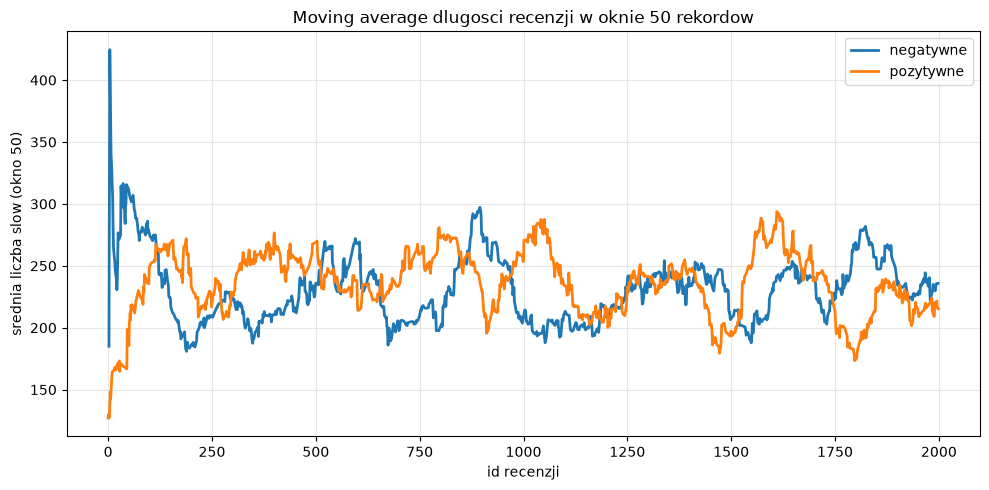


Wniosek: ranking i moving average wymagaja window functions, bo liczymy wartosci per wiersz w kontekscie klasy i uporzadkowania po id.


In [32]:
# Zadanie 5.1: window functions
import matplotlib.pyplot as plt
from pyspark.sql import functions as F
from pyspark.sql.window import Window

df_words = globals().get("df_words")
if df_words is None:
    raise RuntimeError("Uruchom najpierw komorke 18 (setup Spark + df_words), a dopiero potem komorke 20.")

rank_window = Window.partitionBy("label").orderBy(F.col("word_count").desc(), F.col("id").asc())
class_avg_window = Window.partitionBy("label")
moving_window = Window.partitionBy("label").orderBy(F.col("id").asc()).rowsBetween(-49, 0)

df_window = (df_words
    .select("id", "label", "text", "word_count")
    .withColumn("ranking", F.row_number().over(rank_window))
    .withColumn("avg_word_count_klasy", F.avg("word_count").over(class_avg_window))
    .withColumn("diff_from_class_avg", F.round(F.col("word_count") - F.col("avg_word_count_klasy"), 2))
    .withColumn("moving_avg_50", F.round(F.avg("word_count").over(moving_window), 2))
)

print("-- Top 3 najdluzsze recenzje per klasa --")
top3_per_class = (df_window
    .filter(F.col("ranking") <= 3)
    .select("id", "label", "word_count", "ranking")
    .orderBy("label", "ranking")
)
top3_per_class.show(truncate=False)

print("\n-- Przyklad roznicy od sredniej dlugosci w klasie --")
(df_window
    .select("id", "label", "word_count", "avg_word_count_klasy", "diff_from_class_avg")
    .orderBy("label", "id")
    .show(10, truncate=False)
)

moving_avg_pd = (df_window
    .select("id", "label", "moving_avg_50")
    .orderBy("label", "id")
    .toPandas()
)

label_names = {0: "negatywne", 1: "pozytywne"}
plt.figure(figsize=(10, 5))
for label_value, label_df in moving_avg_pd.groupby("label"):
    plt.plot(label_df["id"], label_df["moving_avg_50"], label=label_names.get(label_value, str(label_value)), linewidth=2)

plt.title("Moving average dlugosci recenzji w oknie 50 rekordow")
plt.xlabel("id recenzji")
plt.ylabel("srednia liczba slow (okno 50)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nWniosek: ranking i moving average wymagaja window functions, bo liczymy wartosci per wiersz w kontekscie klasy i uporzadkowania po id.")

---

# Lab 6 — Data Quality (jakość danych)

## Teoria w trzech zdaniach

**Data Quality** to nie audyt po wszystkim — to **kontrakt** który dane muszą spełnić zanim wejdą do pipeline'u. Sześć wymiarów: kompletność, unikalność, poprawność, zgodność, świeżość, integralność.

Współczesny stack: `pandera`/`great_expectations` dla **deklaratywnych testów**, `pandas-profiling` (teraz `ydata-profiling`) dla **raportów eksploracyjnych**, własne **walidatory** dla reguł biznesowych.

**Reguła:** jeśli nie potrafisz w jednym zdaniu opisać co znaczy "dobre dane" dla Twojego problemu, nie powinieneś jeszcze trenować modelu.

## Przykład rozwiązany: profilowanie imdb — wykrywanie anomalii

In [33]:
import pandas as pd

# Wczytaj wieksza probke
samples_dq = get_imdb_subset("train", 2000)
df_pd = pd.DataFrame(samples_dq, columns=["text", "label"])
df_pd["word_count"] = df_pd["text"].str.split().str.len()
df_pd["char_count"] = df_pd["text"].str.len()

# Profil podstawowy
print("=== KOMPLETNOSC ===")
nulls = df_pd.isnull().sum()
print(f"Nulle: {dict(nulls)}")

print("\n=== UNIKALNOSC ===")
dup_count = df_pd["text"].duplicated().sum()
print(f"Duplikaty tekstu: {dup_count}")

print("\n=== ROZKLAD LABELI ===")
print(df_pd["label"].value_counts(normalize=True).rename("frac"))
balance_ratio = df_pd["label"].value_counts().min() / df_pd["label"].value_counts().max()
print(f"Stosunek mniejszosci do wiekszosci: {balance_ratio:.3f} (1.0 = idealnie zbalansowane)")

print("\n=== ANOMALIE DLUGOSCI ===")
p99 = df_pd["word_count"].quantile(0.99)
p01 = df_pd["word_count"].quantile(0.01)
outliers = df_pd[(df_pd["word_count"] > p99) | (df_pd["word_count"] < p01)]
print(f"P1: {p01:.0f}, P99: {p99:.0f}, outlierow (poza P1-P99): {len(outliers)}")

print("\n=== ANOMALIE TRESCI ===")
has_html = df_pd["text"].str.contains(r"<[^>]+>", regex=True).sum()
very_short = (df_pd["word_count"] < 5).sum()
print(f"Tekst zawiera HTML tagi: {has_html} ({has_html/len(df_pd)*100:.1f}%)")
print(f"Bardzo krotkie recenzje (<5 slow): {very_short}")

print("\nINSIGHT: imdb ma duzo HTML pozostalosci (<br />). Trzeba je czyscic przed treningiem!")

  [timer] get_imdb_subset -> 0.00s
=== KOMPLETNOSC ===
Nulle: {'text': np.int64(0), 'label': np.int64(0), 'word_count': np.int64(0), 'char_count': np.int64(0)}

=== UNIKALNOSC ===
Duplikaty tekstu: 0

=== ROZKLAD LABELI ===
label
1    0.5
0    0.5
Name: frac, dtype: float64
Stosunek mniejszosci do wiekszosci: 1.000 (1.0 = idealnie zbalansowane)

=== ANOMALIE DLUGOSCI ===
P1: 42, P99: 889, outlierow (poza P1-P99): 39

=== ANOMALIE TRESCI ===
Tekst zawiera HTML tagi: 1189 (59.5%)
Bardzo krotkie recenzje (<5 slow): 0

INSIGHT: imdb ma duzo HTML pozostalosci (<br />). Trzeba je czyscic przed treningiem!


## Zadanie 6.1 — Kontrakt danych + raport JSON

**Cel:** zaimplementuj prosty *Data Quality Framework* w czystym Pythonie i wygeneruj raport o jakości datasetu.

**Wymagania:**

1. Klasa `DataContract` z metodą `add_rule(name, callable, severity)` (severity ∈ {`info`, `warning`, `error`}).
2. Klasa `DataValidator` która iteruje po regułach kontraktu i zwraca raport: `{rule_name: {passed: bool, severity, details}}`.
3. Zdefiniuj kontrakt dla imdb z **minimum 6 regułami**:
   - `no_nulls` — brak NULL w `text` i `label`
   - `labels_in_set` — wszystkie labele są w {0, 1}
   - `min_word_count` — każda recenzja ma min. 5 słów
   - `max_word_count` — żadna recenzja > 2000 słów (sanity)
   - `no_duplicates` — brak duplikatów `text`
   - `class_balance` — stosunek klas między 0.5 a 1.5
4. Reguły o severity `error` które zawiodły powinny rzucić wyjątek (fail fast). Reszta jest tylko ostrzeżeniem.
5. Wygeneruj raport w pliku `_workspace/data_quality_report.json` z timestampem.

**Bonus:** zaimplementuj `severity="warning"` regułę `no_html_tags` i pokaż że *raport* o niej mówi, ale walidacja nie zawodzi.

In [34]:
# Zadanie 6.1: DataContract + DataValidator
import json
from datetime import datetime
from dataclasses import dataclass
from pathlib import Path
from typing import Callable

WORKDIR = globals().get("WORKDIR", Path("./_workspace"))
WORKDIR.mkdir(exist_ok=True)

df_pd = globals().get("df_pd")
if df_pd is None:
    import pandas as pd
    samples_dq = get_imdb_subset("train", 2000)
    df_pd = pd.DataFrame(samples_dq, columns=["text", "label"])
    df_pd["word_count"] = df_pd["text"].str.split().str.len()
    df_pd["char_count"] = df_pd["text"].str.len()

@dataclass
class Rule:
    name: str
    check: Callable
    severity: str = "warning"  # info | warning | error

class DataContract:
    def __init__(self, name: str):
        self.name = name
        self.rules: list[Rule] = []
    
    def add_rule(self, name: str, check: Callable, severity: str = "warning"):
        allowed = {"info", "warning", "error"}
        if severity not in allowed:
            raise ValueError(f"Nieznany severity: {severity}")
        self.rules.append(Rule(name=name, check=check, severity=severity))

class DataValidator:
    def __init__(self, contract: DataContract):
        self.contract = contract
    
    def validate(self, df) -> dict:
        report: dict[str, dict] = {}
        for rule in self.contract.rules:
            passed, details = rule.check(df)
            report[rule.name] = {
                "passed": bool(passed),
                "severity": rule.severity,
                "details": details,
            }
            if rule.severity == "error" and not passed:
                raise ValueError(f"Regula krytyczna nie przeszla: {rule.name} -> {details}")
        return report

def rule_no_nulls(df):
    null_count = int(df[["text", "label"]].isnull().sum().sum())
    return null_count == 0, {"null_count": null_count}

def rule_labels_in_set(df):
    invalid_labels = sorted(set(df["label"].dropna()) - {0, 1})
    return len(invalid_labels) == 0, {"invalid_labels": invalid_labels}

def rule_min_word_count(df):
    too_short = int((df["word_count"] < 5).sum())
    return too_short == 0, {"rows_below_5_words": too_short}

def rule_max_word_count(df):
    too_long = int((df["word_count"] > 2000).sum())
    return too_long == 0, {"rows_above_2000_words": too_long}

def rule_no_duplicates(df):
    duplicate_count = int(df["text"].duplicated().sum())
    return duplicate_count == 0, {"duplicate_text_rows": duplicate_count}

def rule_class_balance(df):
    counts = df["label"].value_counts()
    if counts.empty or counts.max() == 0:
        return False, {"ratio": None, "counts": counts.to_dict()}
    ratio = float(counts.min() / counts.max())
    return 0.5 <= ratio <= 1.5, {"ratio": round(ratio, 4), "counts": counts.to_dict()}

contract = DataContract("imdb_data_contract")
contract.add_rule("no_nulls", rule_no_nulls, severity="error")
contract.add_rule("labels_in_set", rule_labels_in_set, severity="error")
contract.add_rule("min_word_count", rule_min_word_count, severity="warning")
contract.add_rule("max_word_count", rule_max_word_count, severity="error")
contract.add_rule("no_duplicates", rule_no_duplicates, severity="error")
contract.add_rule("class_balance", rule_class_balance, severity="warning")

validator = DataValidator(contract)
report = validator.validate(df_pd)

report_path = WORKDIR / "data_quality_report.json"
report_payload = {
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "contract": contract.name,
    "report": report,
}
report_path.write_text(json.dumps(report_payload, ensure_ascii=False, indent=2), encoding="utf-8")

print("=== RAPORT DATA QUALITY ===")
for rule_name, rule_result in report.items():
    status = "PASS" if rule_result["passed"] else "FAIL"
    print(f"{rule_name}: {status} [{rule_result['severity']}] -> {rule_result['details']}")
print(f"\nRaport zapisany do: {report_path.resolve()}")

=== RAPORT DATA QUALITY ===
no_nulls: PASS [error] -> {'null_count': 0}
labels_in_set: PASS [error] -> {'invalid_labels': []}
min_word_count: PASS [warning] -> {'rows_below_5_words': 0}
max_word_count: PASS [error] -> {'rows_above_2000_words': 0}
no_duplicates: PASS [error] -> {'duplicate_text_rows': 0}
class_balance: PASS [warning] -> {'ratio': 1.0, 'counts': {1: 1000, 0: 1000}}

Raport zapisany do: C:\Users\mitan\Magisterka\AAP_LAB_TASKS\zestaw_zaliczeniowy\_workspace\data_quality_report.json


---

# Sekcja kontrolna — co umiesz po tym zestawie

Po ukończeniu wszystkich 6 zadań powinieneś **bez przygotowania** odpowiedzieć na:

1. **Dekorator:** kiedy `functools.wraps` jest konieczny, a kiedy można sobie odpuścić?
2. **Concurrency:** dlaczego threading nie przyspieszy obliczeń, a multiprocessing przyspieszy?
3. **Testowanie:** kiedy lepiej parametrize, a kiedy osobne testy?
4. **Bazy:** co znaczy *schema-on-read*? Daj praktyczny przykład gdy to plus, a kiedy minus.
5. **Spark:** co to znaczy że transformacja jest "lazy"? Daj przykład **kiedy to boli** w debugowaniu.
6. **Data Quality:** różnica między *audytem* a *kontraktem* danych. W produkcji potrzebujesz obu — dlaczego?

## Co dalej?

- **Pakowanie:** `pyproject.toml`, `poetry`, dystrybucja przez `pip`
- **CI/CD:** GitHub Actions, pre-commit hooks, automated testing
- **Observability:** logging structured (`structlog`), metryki (`prometheus_client`), tracing (`opentelemetry`)
- **Orchestration:** Apache Airflow / Prefect / Dagster do *prawdziwych* pipeline'ów
- **Workshops:** [Real Python](https://realpython.com), [Talk Python To Me](https://talkpython.fm) podcast

In [35]:
# Sprzatanie
try:
    spark.stop()
    print("Spark zatrzymany.")
except NameError:
    pass
print(f"Workspace: {WORKDIR.resolve()}")
print("Wszystkie cache i artefakty zostaja -- usun recznie jesli potrzeba.")

Spark zatrzymany.
Workspace: C:\Users\mitan\Magisterka\AAP_LAB_TASKS\zestaw_zaliczeniowy\_workspace
Wszystkie cache i artefakty zostaja -- usun recznie jesli potrzeba.
